In [1]:
import pandas as pd

df = pd.read_csv("../results/vary_n_0_1.csv")

# Ensure N and K are treated as integers
df['N'] = df['N'].astype(int)

# Create "Setting" column for the X-axis label in (N, K) format
df['Setting'] = df['N'].astype(str)

# Sort the dataframe
df = df.sort_values(by=['N'])

# Inspect
df.tail()

,N,K,M,PGEM_acc_mean,PGEM_acc_std,PGEM_wacc_mean,PGEM_wacc_std,PGEM_tau_mean,PGEM_tau_std,BT_acc_mean,...,HTCV_wacc_std,HTCV_tau_mean,HTCV_tau_std,HBTL_acc_mean,HBTL_acc_std,HBTL_wacc_mean,HBTL_wacc_std,HBTL_tau_mean,HBTL_tau_std,Setting
3,500,1000,20000,0.902693,0.005751,0.978410,0.003427,0.805387,0.011503,0.899651,...,0.002867,0.798094,0.009571,0.902051,0.005516,0.978134,0.003476,0.804101,0.011032,500
4,1000,1000,20000,0.859397,0.003379,0.952841,0.003376,0.718794,0.006758,0.863830,...,0.004087,0.675896,0.008542,0.850399,0.004176,0.946832,0.003876,0.700798,0.008353,1000
5,2000,1000,20000,0.794264,0.006173,0.897578,0.007821,0.588528,0.012345,0.813062,...,0.006932,0.562738,0.009626,0.778940,0.005679,0.881360,0.007698,0.557881,0.011357,2000
6,2250,1000,20000,0.779906,0.010484,0.881637,0.011858,0.559812,0.020968,0.802319,...,0.010264,0.538224,0.016753,0.766502,0.009646,0.866095,0.011795,0.533004,0.019292,2250
7,2500,1000,20000,0.765671,0.004544,0.868222,0.005724,0.531343,0.009087,0.794178,...,0.006216,0.520027,0.009778,0.754361,0.005453,0.855908,0.007679,0.508722,0.010907,2500


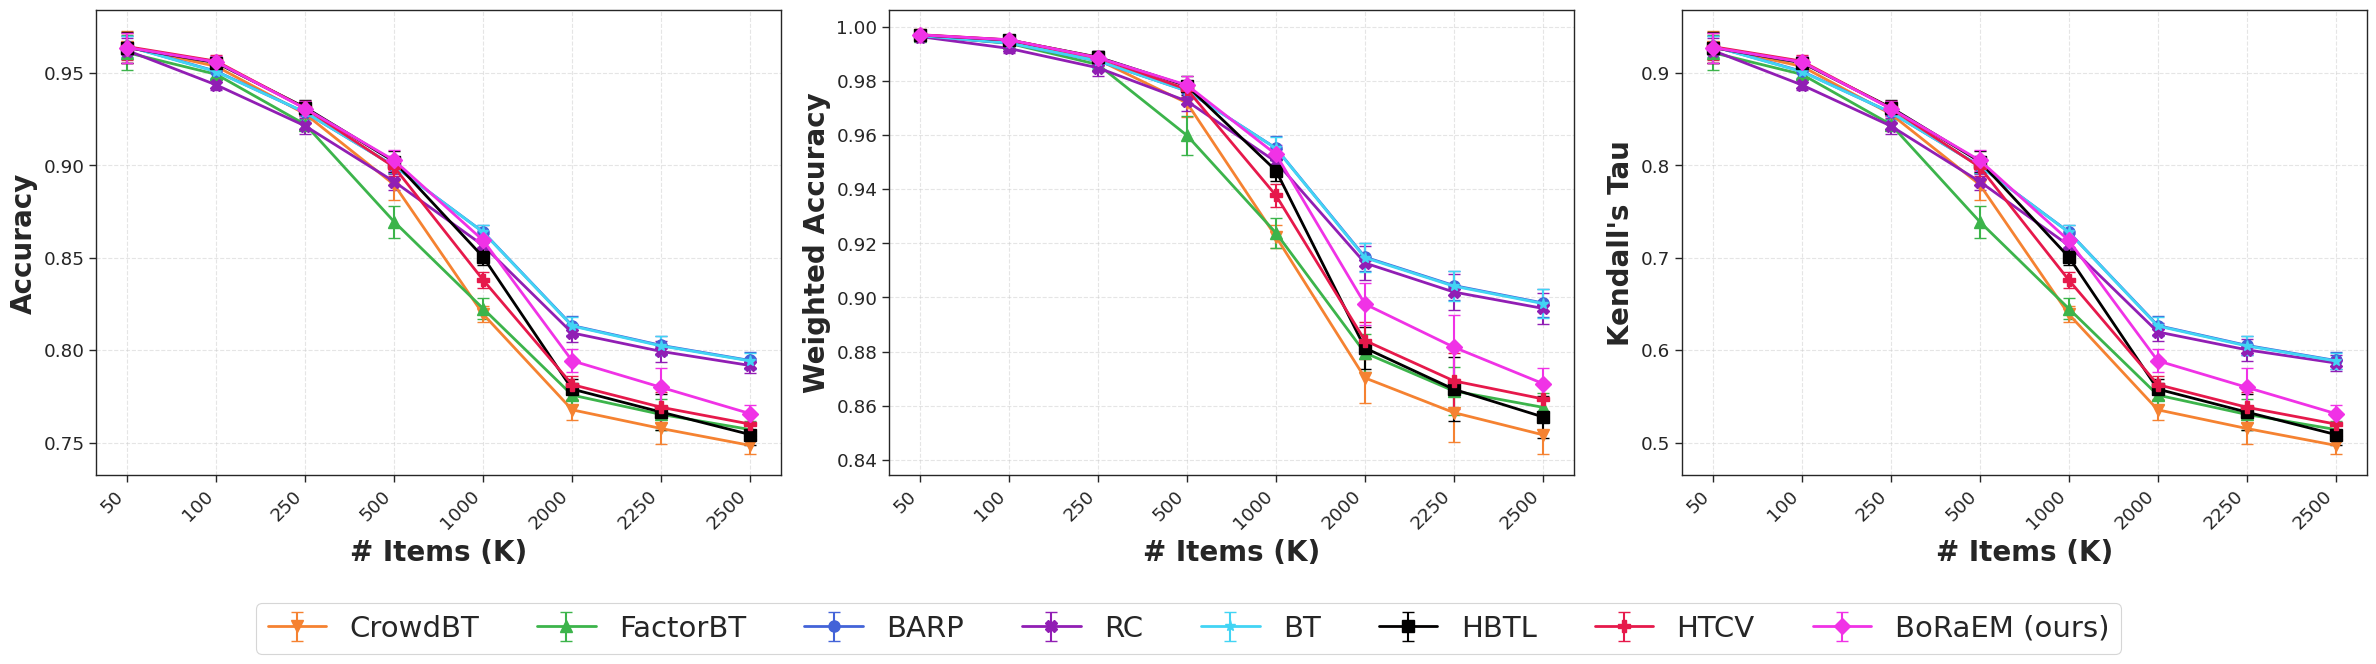

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Extract the sorted settings and create an index for plotting
settings_order = df['Setting'].values
x_indices = np.arange(len(settings_order))

# Define the parameters
methods = ['CrowdBT', 'FactorBT', 'BARP', 'RC', 'BT','HBTL', 'HTCV', 'PGEM']
metrics = ['acc', 'wacc', 'tau']

# Display names for the legend
method_display = {
    'CrowdBT': 'CrowdBT',
    'FactorBT': 'FactorBT',
    'BARP': 'BARP',
    'RC': 'RC',
    'BT': 'BT',
    'HBTL': 'HBTL',
    'HTCV': 'HTCV',
    'PGEM': 'BoRaEM (ours)'
}

# Six distinct high-contrast colors
colors = ["#F58231" , "#3CB44B", "#4363D8", "#911EB4", "#42D4F4", "#010000", "#E6194B", "#F032E6"]



# colors = sns.color_palette("husl", len(methods))
markers = ['v',  '^', 'o', 'X', '*', 's', 'P', 'D']

# Styling
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

# Create a single figure with 3 subplots stacked vertically
# sharex=True ensures that only the bottom plot needs x-labels
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True)
title_map = {'acc': 'Accuracy', 'wacc': 'Weighted Accuracy', 'tau': "Kendall's Tau"}

handles, labels = [], []

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    for j, method in enumerate(methods):
        mean_col = f"{method}_{metric}_mean"
        std_col = f"{method}_{metric}_std"
        
        means = df[mean_col].values
        stds = df[std_col].values
        
        line = ax.errorbar(
            x_indices, means, yerr=stds,
            label=method_display[method],
            marker=markers[j], markersize=8,
            capsize=4, elinewidth=1.5, linewidth=2,
            color=colors[j]
        )
        
        # Collect handles for the legend from the first subplot
        if i == 0:
            handles.append(line)
            labels.append(method_display[method])
        
    # Formatting each subplot
    ax.set_ylabel(title_map.get(metric, metric.upper()), fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Only show the X-axis labels on the bottom subplot
#     if i == 2:
    ax.set_xticks(x_indices)
    ax.set_xticklabels(settings_order, rotation=45, ha='right')
    ax.set_xlabel('# Items (K)', fontsize=20, fontweight='bold')

# Add a single legend for the entire figure at the top
fig.legend(handles, labels, title="", loc='upper center', 
           bbox_to_anchor=(0.5, 0), ncol=8, 
           fontsize=21, title_fontsize=21, frameon=True)

plt.tight_layout()

os.makedirs("svgs",exist_ok=True)
os.makedirs("pdfs",exist_ok=True)

# --- SAVING AS SVG AND PDF ---
# Saving as SVG (Scalable Vector Graphics)
plt.savefig('svgs/vary_n_0_1.svg', format='svg', bbox_inches='tight')

# Saving as PDF
plt.savefig('pdfs/vary_n_0_1.pdf', format='pdf', bbox_inches='tight')

plt.show()

In [3]:
import pandas as pd

df = pd.read_csv("../results/vary_n_-1_1.csv")

# Ensure N and K are treated as integers
df['N'] = df['N'].astype(int)

# Create "Setting" column for the X-axis label in (N, K) format
df['Setting'] = df['N'].astype(str)

# Sort the dataframe
df = df.sort_values(by=['N'])

# Inspect
df.tail()

,N,K,M,PGEM_acc_mean,PGEM_acc_std,PGEM_wacc_mean,PGEM_wacc_std,PGEM_tau_mean,PGEM_tau_std,BT_acc_mean,...,HTCV_wacc_std,HTCV_tau_mean,HTCV_tau_std,HBTL_acc_mean,HBTL_acc_std,HBTL_wacc_mean,HBTL_wacc_std,HBTL_tau_mean,HBTL_tau_std,Setting
3,500,1000,20000,0.901074,0.003165,0.978189,0.001751,0.802148,0.006330,0.503125,...,0.007807,0.687617,0.018489,0.900916,0.002962,0.978128,0.001545,0.801832,0.005924,500
4,1000,1000,20000,0.857475,0.004982,0.952318,0.003370,0.714951,0.009964,0.502291,...,0.019936,0.536241,0.029804,0.848388,0.006480,0.946125,0.004159,0.696776,0.012961,1000
5,2000,1000,20000,0.764781,0.083484,0.858351,0.114180,0.529563,0.166968,0.500114,...,0.054663,0.190966,0.073747,0.777733,0.008206,0.880698,0.010079,0.555466,0.016413,2000
6,2250,1000,20000,0.751997,0.073504,0.846270,0.096608,0.503994,0.147008,0.502074,...,0.066021,0.097590,0.090866,0.669271,0.111166,0.734968,0.155405,0.338541,0.222331,2250
7,2500,1000,20000,0.743471,0.059684,0.838850,0.081057,0.486942,0.119367,0.502961,...,0.039096,0.089668,0.053051,0.707959,0.051204,0.794063,0.068451,0.415919,0.102409,2500


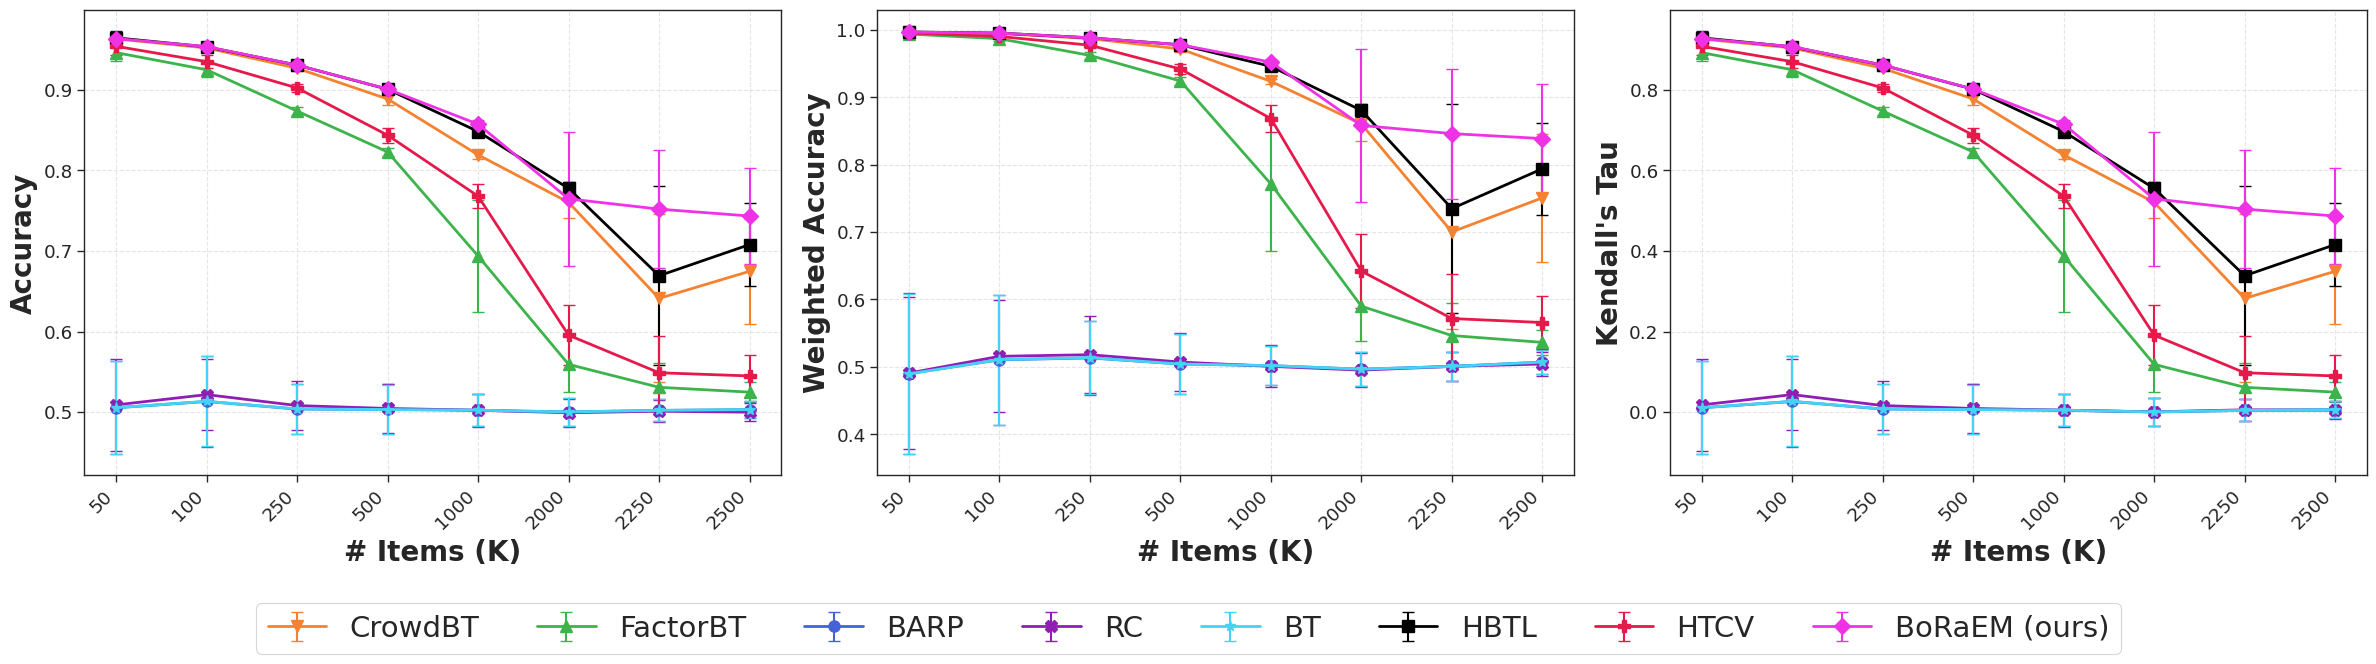

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Extract the sorted settings and create an index for plotting
settings_order = df['Setting'].values
x_indices = np.arange(len(settings_order))

# Define the parameters
methods = ['CrowdBT', 'FactorBT', 'BARP', 'RC', 'BT','HBTL', 'HTCV', 'PGEM']
metrics = ['acc', 'wacc', 'tau']

# Six distinct high-contrast colors
colors = ["#F58231" , "#3CB44B", "#4363D8", "#911EB4", "#42D4F4", "#010000", "#E6194B", "#F032E6"]

# colors = sns.color_palette("husl", len(methods))
markers = ['v',  '^', 'o', 'X', '*', 's', 'P', 'D']

# Styling
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

# Create a single figure with 3 subplots stacked vertically
# sharex=True ensures that only the bottom plot needs x-labels
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True)
title_map = {'acc': 'Accuracy', 'wacc': 'Weighted Accuracy', 'tau': "Kendall's Tau"}

handles, labels = [], []

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    for j, method in enumerate(methods):
        mean_col = f"{method}_{metric}_mean"
        std_col = f"{method}_{metric}_std"
        
        means = df[mean_col].values
        stds = df[std_col].values
        
        line = ax.errorbar(
            x_indices, means, yerr=stds,
            label=method_display[method],
            marker=markers[j], markersize=8,
            capsize=4, elinewidth=1.5, linewidth=2,
            color=colors[j]
        )
        
        # Collect handles for the legend from the first subplot
        if i == 0:
            handles.append(line)
            labels.append(method_display[method])
        
    # Formatting each subplot
    ax.set_ylabel(title_map.get(metric, metric.upper()), fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Only show the X-axis labels on the bottom subplot
#     if i == 2:
    ax.set_xticks(x_indices)
    ax.set_xticklabels(settings_order, rotation=45, ha='right')
    ax.set_xlabel('# Items (K)', fontsize=20, fontweight='bold')

# Add a single legend for the entire figure at the top
fig.legend(handles, labels, title="", loc='upper center', 
           bbox_to_anchor=(0.5, 0), ncol=8, 
           fontsize=21, title_fontsize=21, frameon=True)

plt.tight_layout()

os.makedirs("svgs",exist_ok=True)
os.makedirs("pdfs",exist_ok=True)

# --- SAVING AS SVG AND PDF ---
# Saving as SVG (Scalable Vector Graphics)
plt.savefig('svgs/vary_n_-1_1.svg', format='svg', bbox_inches='tight')

# Saving as PDF
plt.savefig('pdfs/vary_n_-1_1.pdf', format='pdf', bbox_inches='tight')

plt.show()